# GSM8K Llama Run Summary Analysis

Starter notebook: load the summary CSV and inspect the available columns.

In [ ]:
from pathlib import Path

import pandas as pd


In [ ]:
SUMMARY_CSV = Path('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/runs/gsm8k_llama_nonprivate_run_summary.csv')
SUMMARY_CSV


In [ ]:
df = pd.read_csv(SUMMARY_CSV)
print('shape:', df.shape)
display(df.head())


In [ ]:
core_count_match = df['run_dir'].astype(str).str.extract(r'_cores(\d+)_rank')
df['core_count'] = pd.to_numeric(core_count_match[0], errors='coerce')
display(df[['run_dir', 'core_count']].head())


In [ ]:
columns_df = pd.DataFrame({
    'column_name': df.columns,
    'dtype': [str(df[col].dtype) for col in df.columns],
})
display(columns_df)


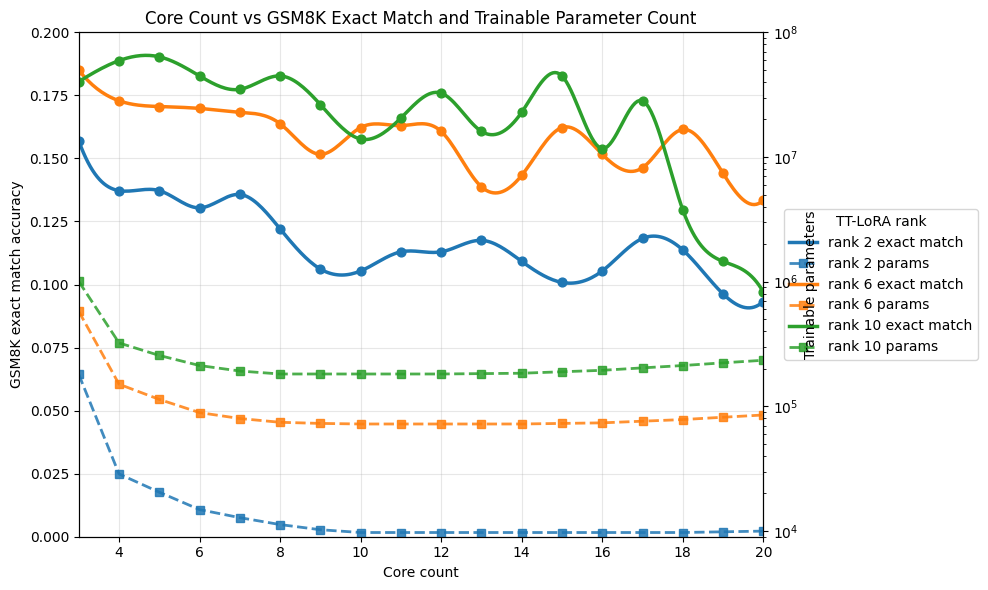

In [19]:
import numpy as np
from scipy.interpolate import make_interp_spline

df['ttlora_rank'] = pd.to_numeric(df['ttlora_rank'], errors='coerce')
df['trainable_parameters'] = pd.to_numeric(df['trainable_parameters'], errors='coerce')

plot_df = (
    df[['core_count', 'ttlora_rank', 'gsm8k_exact_match_accuracy', 'trainable_parameters']]
    .dropna()
    .sort_values(['ttlora_rank', 'core_count'])
)
plot_df = plot_df[plot_df['core_count'] != 2].copy()

exact_match_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='gsm8k_exact_match_accuracy',
    aggfunc='max',
)

param_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='trainable_parameters',
    aggfunc='max',
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rank_values = [rank for rank in exact_match_df.columns.tolist() if pd.notna(rank)]
handles = []
labels = []

for i, rank in enumerate(rank_values):
    color = colors[i % len(colors)]
    x_exact = exact_match_df.index.to_numpy(dtype=float)
    y_exact = exact_match_df[rank].to_numpy(dtype=float)
    if len(x_exact) >= 4:
        x_smooth = np.linspace(x_exact.min(), x_exact.max(), 300)
        y_smooth = make_interp_spline(x_exact, y_exact, k=3)(x_smooth)
    else:
        x_smooth = x_exact
        y_smooth = y_exact
    line1, = ax1.plot(
        x_smooth,
        y_smooth,
        linewidth=2.5,
        color=color,
        label=f'rank {int(rank)} exact match',
    )
    ax1.scatter(
        x_exact,
        y_exact,
        marker='o',
        color=color,
        s=40,
        zorder=3,
    )
    line2, = ax2.plot(
        param_df.index,
        param_df[rank],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.85,
        label=f'rank {int(rank)} params',
    )
    handles.extend([line1, line2])
    labels.extend([f'rank {int(rank)} exact match', f'rank {int(rank)} params'])

ax1.set_title('Core Count vs GSM8K Exact Match and Trainable Parameter Count')
ax1.set_xlabel('Core count')
ax1.set_ylabel('GSM8K exact match accuracy')
ax1.set_xlim(exact_match_df.index.min(), exact_match_df.index.max())
ax1.set_ylim(0.0, 0.20)
ax2.set_ylim(9e3, 1e8)
ax2.set_ylabel('Trainable parameters')
ax2.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend(handles, labels, title='TT-LoRA rank', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


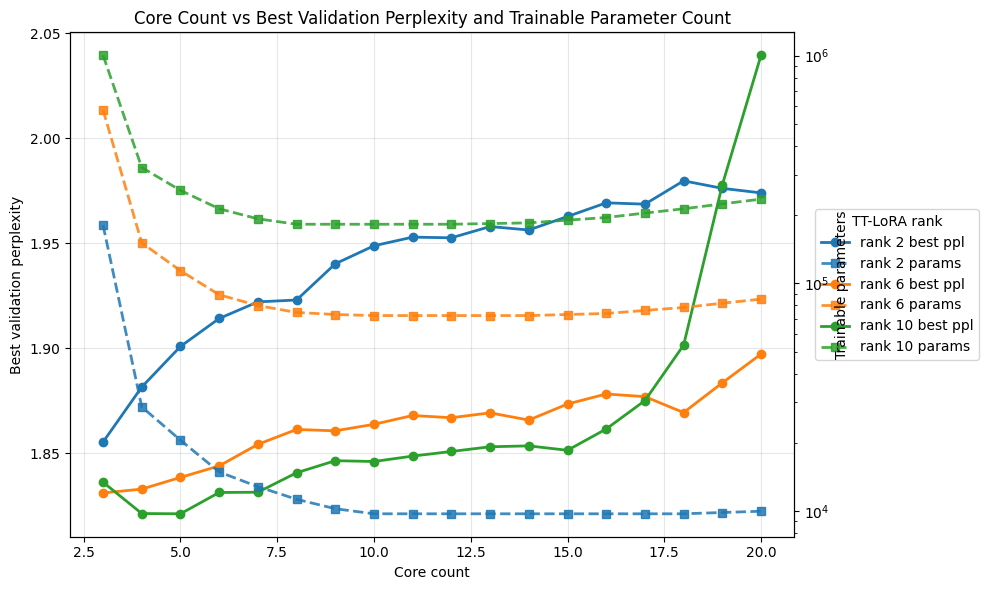

In [20]:
plot_df = (
    df[['core_count', 'ttlora_rank', 'best_validation_perplexity', 'trainable_parameters']]
    .dropna()
    .sort_values(['ttlora_rank', 'core_count'])
)
plot_df = plot_df[plot_df['core_count'] != 2].copy()


best_ppl_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='best_validation_perplexity',
    aggfunc='min',
)

param_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='trainable_parameters',
    aggfunc='max',
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rank_values = [rank for rank in best_ppl_df.columns.tolist() if pd.notna(rank)]
handles = []
labels = []

for i, rank in enumerate(rank_values):
    color = colors[i % len(colors)]
    line1, = ax1.plot(
        best_ppl_df.index,
        best_ppl_df[rank],
        marker='o',
        linewidth=2,
        color=color,
        label=f'rank {int(rank)} best ppl',
    )
    line2, = ax2.plot(
        param_df.index,
        param_df[rank],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.85,
        label=f'rank {int(rank)} params',
    )
    handles.extend([line1, line2])
    labels.extend([f'rank {int(rank)} best ppl', f'rank {int(rank)} params'])

ax1.set_title('Core Count vs Best Validation Perplexity and Trainable Parameter Count')
ax1.set_xlabel('Core count')
ax1.set_ylabel('Best validation perplexity')
ax2.set_ylabel('Trainable parameters')
ax2.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend(handles, labels, title='TT-LoRA rank', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


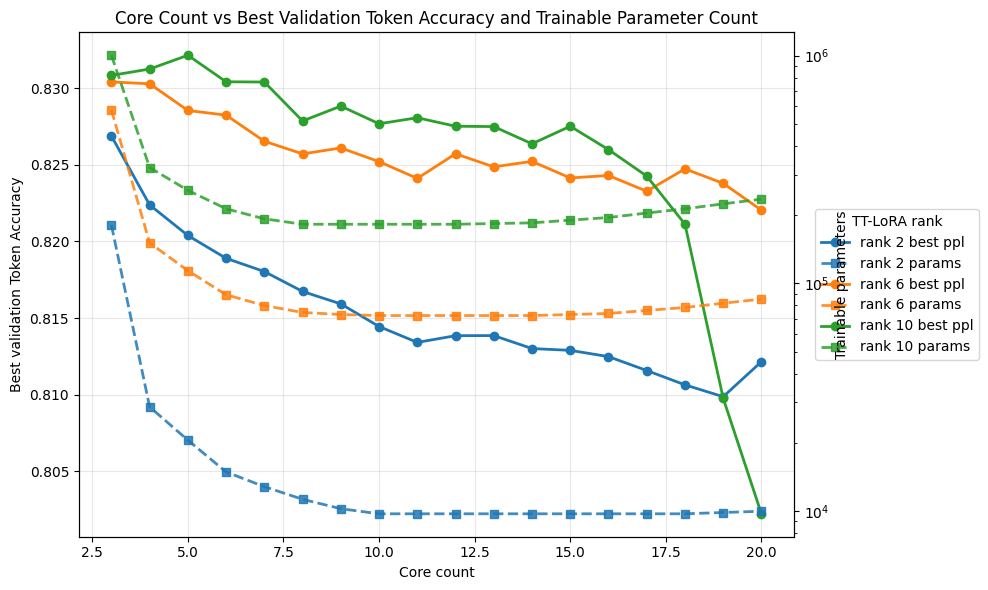

In [21]:
plot_df = (
    df[['core_count', 'ttlora_rank', 'best_validation_token_accuracy', 'trainable_parameters']]
    .dropna()
    .sort_values(['ttlora_rank', 'core_count'])
)
plot_df = plot_df[plot_df['core_count'] != 2].copy()


best_ppl_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='best_validation_token_accuracy',
    aggfunc='max',
)

param_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='trainable_parameters',
    aggfunc='max',
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rank_values = [rank for rank in best_ppl_df.columns.tolist() if pd.notna(rank)]
handles = []
labels = []

for i, rank in enumerate(rank_values):
    color = colors[i % len(colors)]
    line1, = ax1.plot(
        best_ppl_df.index,
        best_ppl_df[rank],
        marker='o',
        linewidth=2,
        color=color,
        label=f'rank {int(rank)} best ppl',
    )
    line2, = ax2.plot(
        param_df.index,
        param_df[rank],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.85,
        label=f'rank {int(rank)} params',
    )
    handles.extend([line1, line2])
    labels.extend([f'rank {int(rank)} best ppl', f'rank {int(rank)} params'])

ax1.set_title('Core Count vs Best Validation Token Accuracy and Trainable Parameter Count')
ax1.set_xlabel('Core count')
ax1.set_ylabel('Best validation Token Accuracy')
ax2.set_ylabel('Trainable parameters')
ax2.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend(handles, labels, title='TT-LoRA rank', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


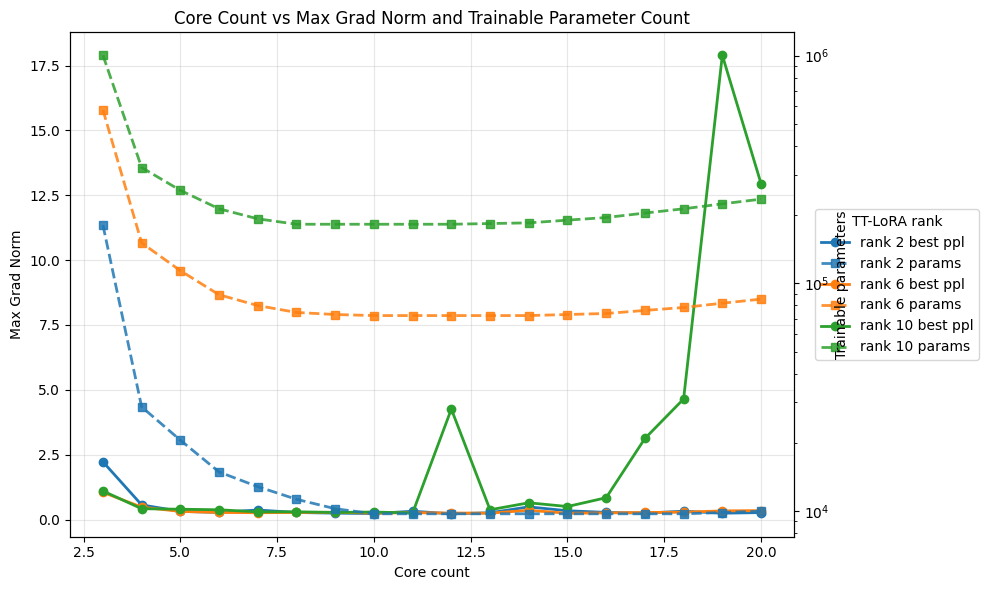

In [29]:
plot_df = (
    df[['core_count', 'ttlora_rank', 'max_grad_norm', 'trainable_parameters']]
    .dropna()
    .sort_values(['ttlora_rank', 'core_count'])
)
plot_df = plot_df[plot_df['core_count'] != 2].copy()




best_ppl_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='max_grad_norm',
    aggfunc='max',
)

param_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='trainable_parameters',
    aggfunc='max',
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rank_values = [rank for rank in best_ppl_df.columns.tolist() if pd.notna(rank)]
handles = []
labels = []

for i, rank in enumerate(rank_values):
    color = colors[i % len(colors)]
    line1, = ax1.plot(
        best_ppl_df.index,
        best_ppl_df[rank],
        marker='o',
        linewidth=2,
        color=color,
        label=f'rank {int(rank)} best ppl',
    )
    line2, = ax2.plot(
        param_df.index,
        param_df[rank],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.85,
        label=f'rank {int(rank)} params',
    )
    handles.extend([line1, line2])
    labels.extend([f'rank {int(rank)} best ppl', f'rank {int(rank)} params'])

ax1.set_title('Core Count vs Max Grad Norm and Trainable Parameter Count')
ax1.set_xlabel('Core count')
ax1.set_ylabel('Max Grad Norm')
ax2.set_ylabel('Trainable parameters')


ax2.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend(handles, labels, title='TT-LoRA rank', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


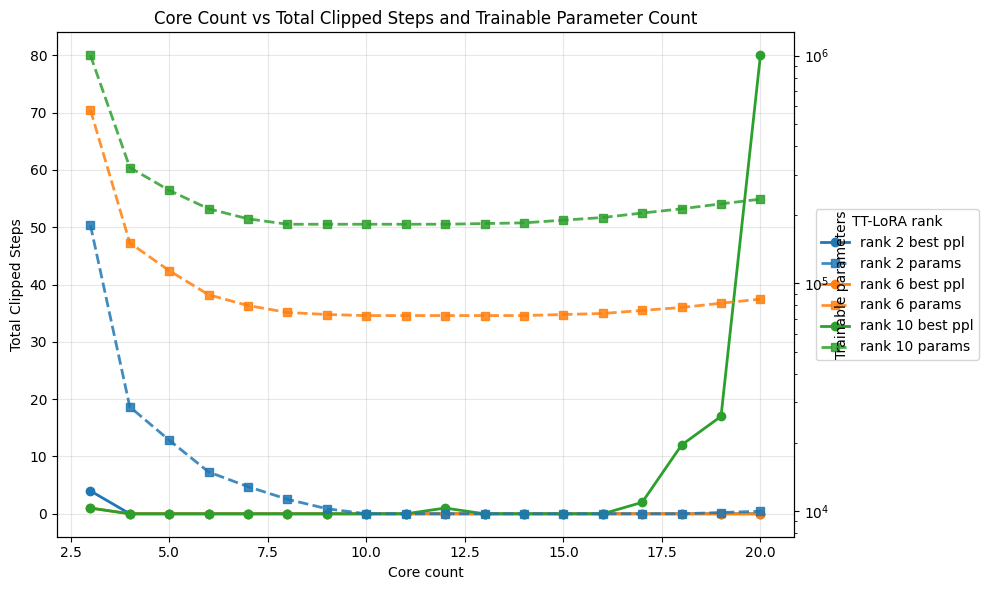

In [28]:
plot_df = (
    df[['core_count', 'ttlora_rank', 'total_clipped_steps', 'trainable_parameters']]
    .dropna()
    .sort_values(['ttlora_rank', 'core_count'])
)
plot_df = plot_df[plot_df['core_count'] != 2].copy()




best_ppl_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='total_clipped_steps',
    aggfunc='max',
)

param_df = plot_df.pivot_table(
    index='core_count',
    columns='ttlora_rank',
    values='trainable_parameters',
    aggfunc='max',
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rank_values = [rank for rank in best_ppl_df.columns.tolist() if pd.notna(rank)]
handles = []
labels = []

for i, rank in enumerate(rank_values):
    color = colors[i % len(colors)]
    line1, = ax1.plot(
        best_ppl_df.index,
        best_ppl_df[rank],
        marker='o',
        linewidth=2,
        color=color,
        label=f'rank {int(rank)} best ppl',
    )
    line2, = ax2.plot(
        param_df.index,
        param_df[rank],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.85,
        label=f'rank {int(rank)} params',
    )
    handles.extend([line1, line2])
    labels.extend([f'rank {int(rank)} best ppl', f'rank {int(rank)} params'])

ax1.set_title('Core Count vs Total Clipped Steps and Trainable Parameter Count')
ax1.set_xlabel('Core count')
ax1.set_ylabel('Total Clipped Steps')
ax2.set_ylabel('Trainable parameters')


ax2.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend(handles, labels, title='TT-LoRA rank', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
